# **Diplomado IA: Inteligencia Artificial II - Parte 1**. <br> Laboratorio 14: Transformers
---
---

**Profesor:**
- Felipe del Río

**Ayudante:**
- Bianca del Solar
---
---

# **Instrucciones Generales**

El siguiente práctico será **individual**. Solo uno debe realizar la entrega. El formato de entregar es el **archivo .ipynb con todas las celdas ejecutadas**. Todas las preguntas deben ser respondida en celdas de texto. No se aceptará el _output_ de una celda de código como respuesta.

**Nombre:** Vicente Zapata

El siguiente práctico cuenta con 2 secciones donde cada una contendrá 1 o más actividades a realizar. Algunas actividades correspondrán a escribir código y otras a responder preguntas.

**Importante.** Para facilitar su ejecución, cada sección puede ser ejecutada independientemente.

Se recomienda **fuertemente** revisar las secciones donde se entrega código porque algunas actividades de código pueden reutilizar el mismo código pero con cambios en algunas líneas.



# **Agenda**

>[Diplomado IA: Inteligencia Artificial II - Parte 1.  Laboratorio 1: Redes Relacionales y Transformers](#scrollTo=tHopPtVaNF1K)

>[Instrucciones Generales](#scrollTo=uIdAKAdELPSl)

>[Agenda](#scrollTo=kEloa5uXLIPK)

>[Parte III: Inspeccionando a CLIP](#scrollTo=ZS3cYFT2TWB9)

>>[Preámbulo](#scrollTo=0dBeU4b818s4)

>>[Cargamos el Modelo](#scrollTo=1D5aBia_ucDJ)

>>[Classificación zero-shot utilizando CLIP](#scrollTo=IPrwC1iF8K0j)

>>>[Dataset Food101](#scrollTo=IPrwC1iF8K0j)

>>>[Actividad 3](#scrollTo=3tABpd-l6-xH)

>>>[Dataset Stanford Cars](#scrollTo=qwbkd4RaAqYt)

>>>[Actividad](#scrollTo=CO9kxJAf6SDO)



# Parte III: Inspeccionando a CLIP

Luego de haber visualizado el funcionamento interno de un transformer, utilizaremos CLIP para ver como se puede aprovechar al máximo esta arquitectura en problemas multi-modales, en este caso, que mezclan texto con imágenes.

Como vimos en clases CLIP es un modelo que nos permite codificar tanto imágenes como texto en vectores de representación comparables entre ellos. Este nos permite ver cual es el texto que más se relaciona con una imágen determinada, y podemos aprovechar este mecanismo para clasificar imágenes con una mayor flexibilidad que en un modelo de clasificación tradicional. En esta tercera parte del laboratorio exploraremos como utilizar CLIP con este fin.

<small>Este notebook fue basado en [el provisto por OpenAI](https://colab.research.google.com/github/openai/clip/blob/master/notebooks/Interacting_with_CLIP.ipynb#scrollTo=uLFS29hnhlY4) con el fin de interacturar con CLIP</small>


## Preámbulo

Primero debemos descargar, instalar e importar las distintas librerías que utilizaremos para este laboratorio.

In [1]:
!pip install ftfy regex tqdm
!pip install git+https://github.com/openai/CLIP.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.3 MB/s eta 0:00:00
  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-xthwi7un
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-xthwi7un
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=7f641432d768eeca81e7950d4e938557163e0310f5ccc3d624a69dc0a879cbb1
  Stored in directory: /tmp/pip-ephem-wheel-cache-8xvnu_9s/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [2]:
import os
import skimage
import random
import IPython.display
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

from collections import OrderedDict
import torch
from pkg_resources import packaging

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

/tmp/ipython-input-888438603.py:11: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import packaging


In [3]:
def bold(text):
    return '\033[1m' + text + '\033[0m'

## Cargamos el Modelo

Luego cargaremos el modelo a utilizar. Utilizando la función `clip.available_models()` podemos listar los diferentes modelos displonibles. Pueden ver más detalles de lo que significa cada modelo en el [paper](https://arxiv.org/pdf/2103.00020.pdf) de CLIP.

Pero, a grandes razgos, **RN** corresponde a un backbone de ResNet para el encoder visual, RN50 correspondría a una ResNet50, y cuando tiene el sufijo `xN`, `x4` por ejemplo, significa que el modelo está escalado para utilizar `N` veces más computo.

Mientras que **ViT** corresponde a un backbone de Vision Transformer. El símbolo `-B` o `-L` corresponde al tamaño del modelo, Base y Large respectivamente y el sufijo `/32` corresponde a que los patches son de `32x32`.

Para este laboratorio usaremos la versión `ViT-B/32`, que está basado en su totalidad en Transformers.



In [4]:
import clip

clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

Primero carguemos un modelo, no tan grande, para utilizar en esta actividad.

El código a continuación descargará los pesos del modelo preentrenado de forma automática. Una vez cargados, podemos veamos algunas características relevantes del modelo.

In [5]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

In [6]:
model, preprocess = clip.load("ViT-B/32")
model.to(device).eval()
input_resolution = model.visual.input_resolution
context_length = model.context_length
vocab_size = model.vocab_size

print("Número de parámetros:", f"{np.sum([int(np.prod(p.shape)) for p in model.parameters()]):,}")
print("Resolución de Entrada:", input_resolution)
print("Tamaño del contexto:", context_length)
print(f"Tamaño del vocabulario: {vocab_size:,}")

100%|███████████████████████████████████████| 338M/338M [00:09<00:00, 36.2MiB/s]


Número de parámetros: 151,277,313
Resolución de Entrada: 224
Tamaño del contexto: 77
Tamaño del vocabulario: 49,408


Podemos acceder al preprocesamiento que CLIP realiza sobre las imágenes, en la variable `preprocess`. Este se basa en las transformaciones de PyTorch para transformar una imágen a un tensor normalizado que el modelo puede recibir (recuerden la clase anterior de data augmentation).

In [7]:
preprocess

Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    <function _convert_image_to_rgb at 0x7f0b6855d3a0>
    ToTensor()
    Normalize(mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711))
)

# Classificación zero-shot utilizando CLIP

Ya teniendo el modelo cargado, veamos como se comporta CLIP para clasificar dos set de datos con características distintas entre ellos.



## Dataset Food101

Primero probaremos en el dataset Food101. Este dataset consiste en 101 comidas diferentes y un total de 101.000 imágenes de estas.

In [8]:
from torchvision.datasets import Food101

food_dataset = Food101(os.path.expanduser("~/.cache"), download=True)

100%|██████████| 5.00G/5.00G [03:43<00:00, 22.4MB/s]


### *Queries* para Predicción

Primero que todo, debemos construir las *queries* que utilizaremos para realizar la clasificación. Recordemos que el modelo que vamos a utilizar está entrenado para entregar una correspondencia entre un texto y una imágen. Por esto, para efectuar clasificaciones tendremos que entregarle la clase que queremos clasificar en forma de texto y para esto usaremos unas *queries* predefinidas.

A continuación, definiremos un *template* para construir nuestras *queries* y veremos algunos ejemplos de las que utilizaremos para clasificar el dataset de Food101.

In [9]:
query_template = 'A photo of {}, a type of food.'
queries = [query_template.format(label.replace('_', ' ')) for label in food_dataset.classes]
tokenized_queries = clip.tokenize(queries).to(device)

In [10]:
for query in queries[:10]:
    print(query)

A photo of apple pie, a type of food.
A photo of baby back ribs, a type of food.
A photo of baklava, a type of food.
A photo of beef carpaccio, a type of food.
A photo of beef tartare, a type of food.
A photo of beet salad, a type of food.
A photo of beignets, a type of food.
A photo of bibimbap, a type of food.
A photo of bread pudding, a type of food.
A photo of breakfast burrito, a type of food.


### Visualización de Predicciones

Seleccione una imagen del dataset utilizando el parámetro `index` para ver las predicciones del modelo. Si prefiere elegir una imágen al azar, active el campo de `random_sample`.

In [11]:
random_sample = True #@param {type:"boolean"}
index = 0 #@param {type:"integer"}


In [12]:
if random_sample:
    index = random.randint(0, len(food_dataset))
original_image, true_label = food_dataset[index]
image = preprocess(original_image)
image_input = image.unsqueeze(0).to(device)

In [13]:
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features = model.encode_text(tokenized_queries).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

Podemos explorar algunos de los resultados que genera CLIP, a continuación veremos las dimensiones de los vectores de características producidos, tanto de texto como de la imagen, además de la matriz de similaridades entre los distintos textos e imágenes que le entregamos.

In [14]:
print('Dim features de la imagen   :', image_features.shape)
print('Dim features del texto      :', text_features.shape)
print('Dim matriz de similaridades :', text_probs.shape)

Dim features de la imagen   : torch.Size([1, 512])
Dim features del texto      : torch.Size([101, 512])
Dim matriz de similaridades : torch.Size([1, 101])


Veamos visualmente como es la predicción de este modelo para el ejemplo seleccionado.

Predicciones Top-5

Clase           Probabilidad
tacos           0.9212
huevos_ranchero 0.0326
chicken_quesadi 0.0235
nachos          0.0139
ceviche         0.0061

Clase verdadera: tacos



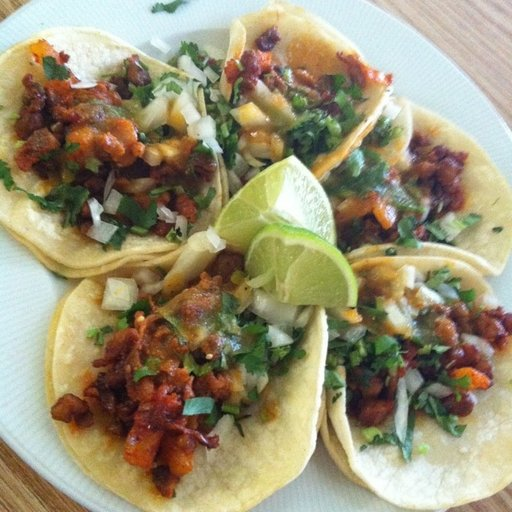

In [15]:
true_label_name = food_dataset.classes[true_label]

print(bold('Predicciones Top-5\n'))
print(bold(f'Clase          '), bold(f'Probabilidad'))
for prob, label in zip(top_probs[0].tolist(), top_labels[0].tolist()):
    label_name = food_dataset.classes[label]
    if true_label_name == label_name:
        print(bold(f'{label_name:15.15s} {prob:.4f}'))
    else:
        print(f'{label_name:15.15s} {prob:.4f}')

print(bold(f'\nClase verdadera: {true_label_name}'), end='\n\n')
original_image

### Rendimiento del Modelo

Ahora midamos el rendimiento que obtiene este modelo si lo usamos para clasificar en el set de test.

Es importante recordar que el modelo que estamos usando no fue entrenado para clasificar en este, por lo que estamos usando una técnica zero-shot.

In [16]:
from tqdm.auto import tqdm
from torch.utils.data import DataLoader

def evaluate_model(model, dataset, queries, batch_size=512):
    test_loader = DataLoader(dataset, batch_size=batch_size)

    in_top1 = in_top5 = total = 0.
    total_batches = len(test_dataset) // batch_size
    for image_inputs, true_labels in tqdm(test_loader, total=total_batches):
        image_inputs = image_inputs.to(device)
        with torch.no_grad():
            image_features = model.encode_image(image_inputs).float()
            image_features /= image_features.norm(dim=-1, keepdim=True)
            text_features = model.encode_text(queries).float()
            text_features /= text_features.norm(dim=-1, keepdim=True)

        text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
        top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

        label_match = (top_labels == true_labels.unsqueeze(-1))
        in_top1 += float(label_match[:,0].sum())
        in_top5 += float(label_match.any(-1).sum())
        total += true_labels.numel()

    top1_acc = in_top1 / total
    top5_acc = in_top5 / total

    return top1_acc, top5_acc

In [17]:
batch_size = 512
test_dataset = Food101(os.path.expanduser("~/.cache"),
                       split='test',
                       transform=preprocess,
                       download=True)

In [18]:
top1_acc, top5_acc = evaluate_model(
    model, test_dataset, tokenized_queries, batch_size=512)

  0%|          | 0/49 [00:00<?, ?it/s]

In [19]:
top1_acc = top1_acc * 100
top5_acc = top5_acc * 100
print(f'Top-1 Accuracy: {top1_acc:.2f}%')
print(f'Top-5 Accuracy: {top5_acc:.2f}%')

Top-1 Accuracy: 84.01%
Top-5 Accuracy: 97.31%


### Actividad 3

Responda las siguientes preguntas

1. **En la celda en donde obtuvimos las dimensiones de distintos resultados generados por el modelo.**

A qué corresponde el valor de la última dimension de los features de texto e imágenes (512 en este caso)

In [20]:
R = "El valor 512 corresponde a la dimensión del espacio de embedding (o espacio latente) donde CLIP  representa tanto las imágenes como el texto.   Es decir, CLIP transforma cualquier imagen o texto en un vector de 512 dimensiones. Este espacio  vectorial compartido es clave porque permite comparar directamente imágenes con texto mediante  operaciones matemáticas como el producto punto o la similitud del coseno.  Piensa en esto como si CLIP \"tradujera\" tanto imágenes como texto a un lenguaje matemático común  de 512 números, donde conceptos similares quedan cerca uno del otro." #@param {type:"string"}

¿Por qué la matriz de similaridad es de `1x101`?

In [21]:
R = 'La matriz de similaridad es de 1x101 porque:  - El 1 representa: UNA imagen que estamos clasificando (el batch size es 1 en este ejemplo) - El 101 representa: las 101 clases posibles del dataset Food101  La matriz contiene las probabilidades de que la imagen pertenezca a cada una de las 101 categorías  de comida. Se calcula multiplicando el vector de features de la imagen (1x512) con la matriz  transpuesta de los features de texto (512x101), lo que resulta en una matriz 1x101.  Cada valor en esta matriz indica qué tan similar es la imagen a cada una de las 101 queries de texto  (cada query describe una clase de comida diferente).' #@param {type:"string"}


2. **Sugiera 2 templates para queries distintos al utilizado previamente y testee su rendimiento.**

El formato de la query debe seguir el mismo que la utilizada previamente y debe cada una debe ser ingresada en un textbox distinto.

Para testear sus templates, simplemente descomente el código más abajo.



In [22]:
Q1 = "A delicious plate of {}" #@param {type:"string"}
Q2 = "This is {} " #@param {type:"string"}

In [43]:
ex1_queries = [Q1.format(label) for label in food_dataset.classes]
ex1_tokenized_queries = clip.tokenize(ex1_queries).to(device)

top1_acc, top5_acc = evaluate_model(
         model, test_dataset, ex1_tokenized_queries, batch_size=512)

top1_acc = top1_acc * 100
top5_acc = top5_acc * 100
print(f'Top-1 Accuracy: {top1_acc:.2f}%')
print(f'Top-5 Accuracy: {top5_acc:.2f}%')

  0%|          | 0/49 [00:00<?, ?it/s]

Top-1 Accuracy: 0.99%
Top-5 Accuracy: 4.95%


In [44]:
ex2_queries = [Q2.format(label) for label in food_dataset.classes]
ex2_tokenized_queries = clip.tokenize(ex2_queries).to(device)

top1_acc, top5_acc = evaluate_model(
     model, test_dataset, ex2_tokenized_queries, batch_size=512)

top1_acc = top1_acc * 100
top5_acc = top5_acc * 100
print(f'Top-1 Accuracy: {top1_acc:.2f}%')
print(f'Top-5 Accuracy: {top5_acc:.2f}%')

  0%|          | 0/49 [00:00<?, ?it/s]

Top-1 Accuracy: 0.99%
Top-5 Accuracy: 4.95%


## Dataset Stanford Cars

Ahora probaremos como le va al modelo en otro dataset, con objetos totalmente distintos a los del anterior. En este caso se trata de un datasets de automoviles. De igual manera que el anterior, el modelo no fue entrenado con estas imágenes en ningún momento.

In [25]:
!mkdir -p data
if not os.path.exists('data/stanford_cars.zip'):
    !gdown --id 1JkcF--obwMvo2ZocIiKEli3EoE0e6ngt -O data/stanford_cars.zip

!unzip -nq data/\*.zip -d data

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1JkcF--obwMvo2ZocIiKEli3EoE0e6ngt
From (redirected): https://drive.google.com/uc?id=1JkcF--obwMvo2ZocIiKEli3EoE0e6ngt&confirm=t&uuid=4ac9244f-d995-451d-8895-ce9852e3f8e7
To: /content/data/stanford_cars.zip
100% 1.97G/1.97G [00:30<00:00, 63.9MB/s]


In [26]:
from torchvision.datasets import StanfordCars

cars_dataset = StanfordCars("data/")

De igual manera que para el dataset anterior, debemos definir nuestras *queries*.

In [27]:
query_template = 'A photo of {}'
queries = [query_template.format(label.replace('_', ' ')) for label in cars_dataset.classes]
tokenized_queries = clip.tokenize(queries).to(device)

In [28]:
for query in queries[:10]:
    print(query)

A photo of AM General Hummer SUV 2000
A photo of Acura RL Sedan 2012
A photo of Acura TL Sedan 2012
A photo of Acura TL Type-S 2008
A photo of Acura TSX Sedan 2012
A photo of Acura Integra Type R 2001
A photo of Acura ZDX Hatchback 2012
A photo of Aston Martin V8 Vantage Convertible 2012
A photo of Aston Martin V8 Vantage Coupe 2012
A photo of Aston Martin Virage Convertible 2012


### Visualización de Predicciones

Igual que con el dataset anterior, seleccione una imagen del dataset utilizando el parámetro `index` para ver las predicciones del modelo. Si prefiere elegir una imágen al azar, active el campo de `random_sample`.

In [29]:
random_sample = True #@param {type:"boolean"}
index = 0 #@param {type:"integer"}


In [30]:
if random_sample:
    index = random.randint(0, len(cars_dataset))
original_image, true_label = cars_dataset[index]
image = preprocess(original_image)
image_input = image.unsqueeze(0).to(device)

In [31]:
with torch.no_grad():
    image_features = model.encode_image(image_input).float()
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features = model.encode_text(tokenized_queries).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

Visualicemos el resultado del modelo.

Predicciones Top-5

Clase                Probabilidad
Audi A5 Coupe 2012   0.5033
Audi S5 Coupe 2012   0.2315
Audi S6 Sedan 2011   0.1681
Audi S4 Sedan 2012   0.0616
Audi S5 Convertible  0.0134

Clase verdadera: Audi S5 Coupe 2012



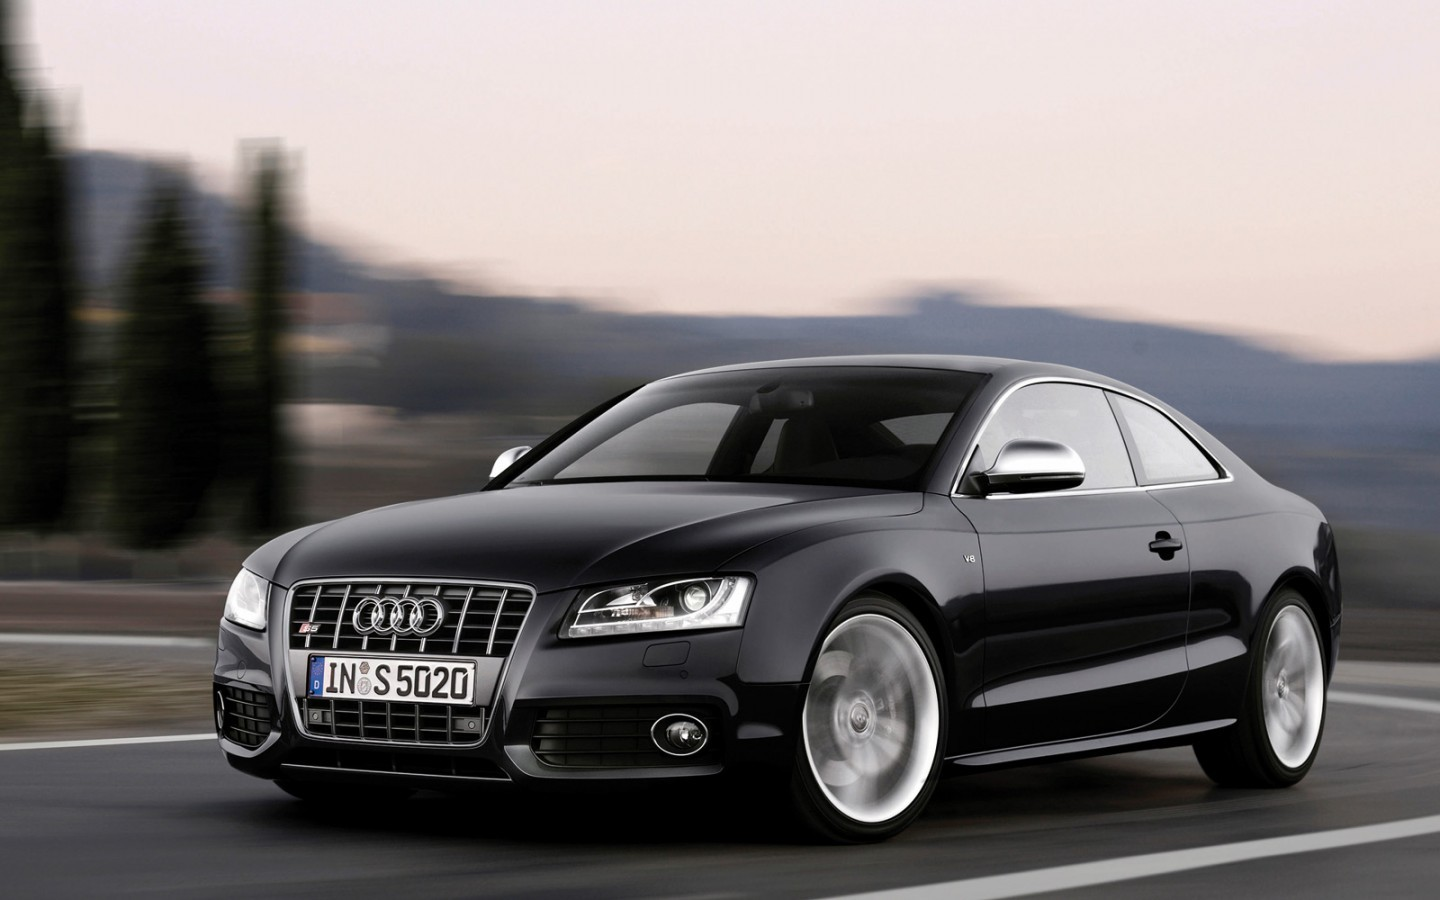

In [32]:
true_label_name = cars_dataset.classes[true_label]

print(bold('Predicciones Top-5\n'))
print(bold(f'Clase               '), bold(f'Probabilidad'))
for prob, label in zip(top_probs[0].tolist(), top_labels[0].tolist()):
    label_name = cars_dataset.classes[label]
    if true_label_name == label_name:
        print(bold(f'{label_name:20.20s} {prob:.4f}'))
    else:
        print(f'{label_name:20.20s} {prob:.4f}')

print(bold(f'\nClase verdadera: {true_label_name}'), end='\n\n')
original_image

### Rendimiento en Test

Ahora, evaluemos el modelo en el set de test del dataset Stanford Cars.

In [33]:
from torch.utils.data import DataLoader

batch_size = 512

test_cars_dataset = StanfordCars('data/', split='test',
                                 transform=preprocess)
test_loader = DataLoader(test_cars_dataset, batch_size=batch_size)

In [34]:
from tqdm.auto import tqdm

in_top1 = in_top5 = total = 0.
total_batches = len(test_cars_dataset) // batch_size
for image_inputs, true_labels in tqdm(test_loader, total=total_batches):
    image_inputs = image_inputs.to(device)
    with torch.no_grad():
        image_features = model.encode_image(image_inputs).float()
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features = model.encode_text(tokenized_queries).float()
        text_features /= text_features.norm(dim=-1, keepdim=True)

    text_probs = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    top_probs, top_labels = text_probs.cpu().topk(5, dim=-1)

    label_match = (top_labels == true_labels.unsqueeze(-1))
    in_top1 += float(label_match[:,0].sum())
    in_top5 += float(label_match.any(-1).sum())
    total += true_labels.numel()

  0%|          | 0/15 [00:00<?, ?it/s]

In [35]:
top1_acc = in_top1 / total * 100
top5_acc = in_top5 / total * 100
print(f'Top-1 Accuracy: {top1_acc:.2f}%')
print(f'Top-5 Accuracy: {top5_acc:.2f}%')

Top-1 Accuracy: 57.93%
Top-5 Accuracy: 89.64%


### Actividad 4

Prueba con tus propias imágenes. Utiliza el código a continuación para subir 5 imágenes distintas y generar 5 queries para estas, las queries deben ser distintas y debe haber una asociada a cada imagen. No necesariamente deben todas seguir el mismo *template*.

Escribe abajo un pequeño análisis del resultados obtenido.

In [36]:
A = "ANÁLISIS DE RESULTADOS:  Al observar la matriz de similitud generada, podemos analizar varios aspectos importantes:  1. **Precisión del Matching imagen-texto:**    - La diagonal de la matriz debería mostrar los valores más altos si cada query corresponde       correctamente a su imagen asociada    - Valores altos en la diagonal (>0.20) indican que CLIP identifica correctamente la relación    - Valores bajos (<0.10) sugieren que el modelo tiene dificultad con esa combinación específica  2. **Confusiones y similitudes semánticas:**    - Los valores altos fuera de la diagonal revelan confusiones interesantes    - Por ejemplo, si \"manzana\" tiene alta similitud con una imagen de pera, indica que CLIP       reconoce la similitud visual/semántica entre frutas    - Estas confusiones nos ayudan a entender qué conceptos son más difíciles de distinguir  3. **Calidad de las queries:**    - Queries más específicas y descriptivas tienden a producir mejores matches    - El formato \"A photo of X, a type of fruit\" proporciona contexto útil al modelo    - Queries muy genéricas pueden resultar en similitudes más distribuidas  4. **Robustez del modelo:**    - Si las 5 imágenes son de categorías muy diferentes, deberíamos ver una matriz casi diagonal    - Esto demostraría que CLIP puede discriminar efectivamente entre conceptos distintos    - La distribución de probabilidades nos indica qué tan \"seguro\" está el modelo de cada match  CONCLUSIÓN: Este ejercicio demuestra la capacidad de CLIP para relacionar imágenes y texto en un espacio  compartido, permitiendo clasificación flexible sin necesidad de reentrenamiento. La calidad  de los resultados depende tanto de las imágenes como de cómo formulamos nuestras queries." #@param {type:"string"}

In [37]:
from google.colab import files

uploaded = files.upload()
filenames = list(uploaded.keys())

Saving Captura de pantalla 2025-03-27 021040.png to Captura de pantalla 2025-03-27 021040.png
Saving Captura de pantalla 2025-03-27 021145.png to Captura de pantalla 2025-03-27 021145.png
Saving Captura de pantalla 2025-03-27 021246.png to Captura de pantalla 2025-03-27 021246.png
Saving Captura de pantalla 2025-03-27 021409.png to Captura de pantalla 2025-03-27 021409.png
Saving Captura de pantalla 2025-03-27 021457.png to Captura de pantalla 2025-03-27 021457.png


In [38]:
from PIL import Image

images = [Image.open(fn) for fn in filenames]
image_inputs = torch.stack([preprocess(image) for image in images]).to(device)

In [45]:
# queries = [
#     "An image of an apple",
#     "An image of an orange",
#     "etc...",
# ]
queries = [
    "A photo of icon build, a type of icon",
    "A photo of icon geolocation, a type of icon",
    "A photo of icon letter, a type of icon",
    "A photo of a icon phone, a type of icon",
    "A photo of a icon linkedin, a type of icon",
]
tokenized_queries = clip.tokenize(queries).to(device)

In [46]:
with torch.no_grad():
    image_features = model.encode_image(image_inputs).float()
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features = model.encode_text(tokenized_queries).float()
    text_features /= text_features.norm(dim=-1, keepdim=True)

similarity = (image_features @ text_features.T).softmax(dim=-1).cpu().numpy().T

In [47]:
similarity.shape

(5, 5)

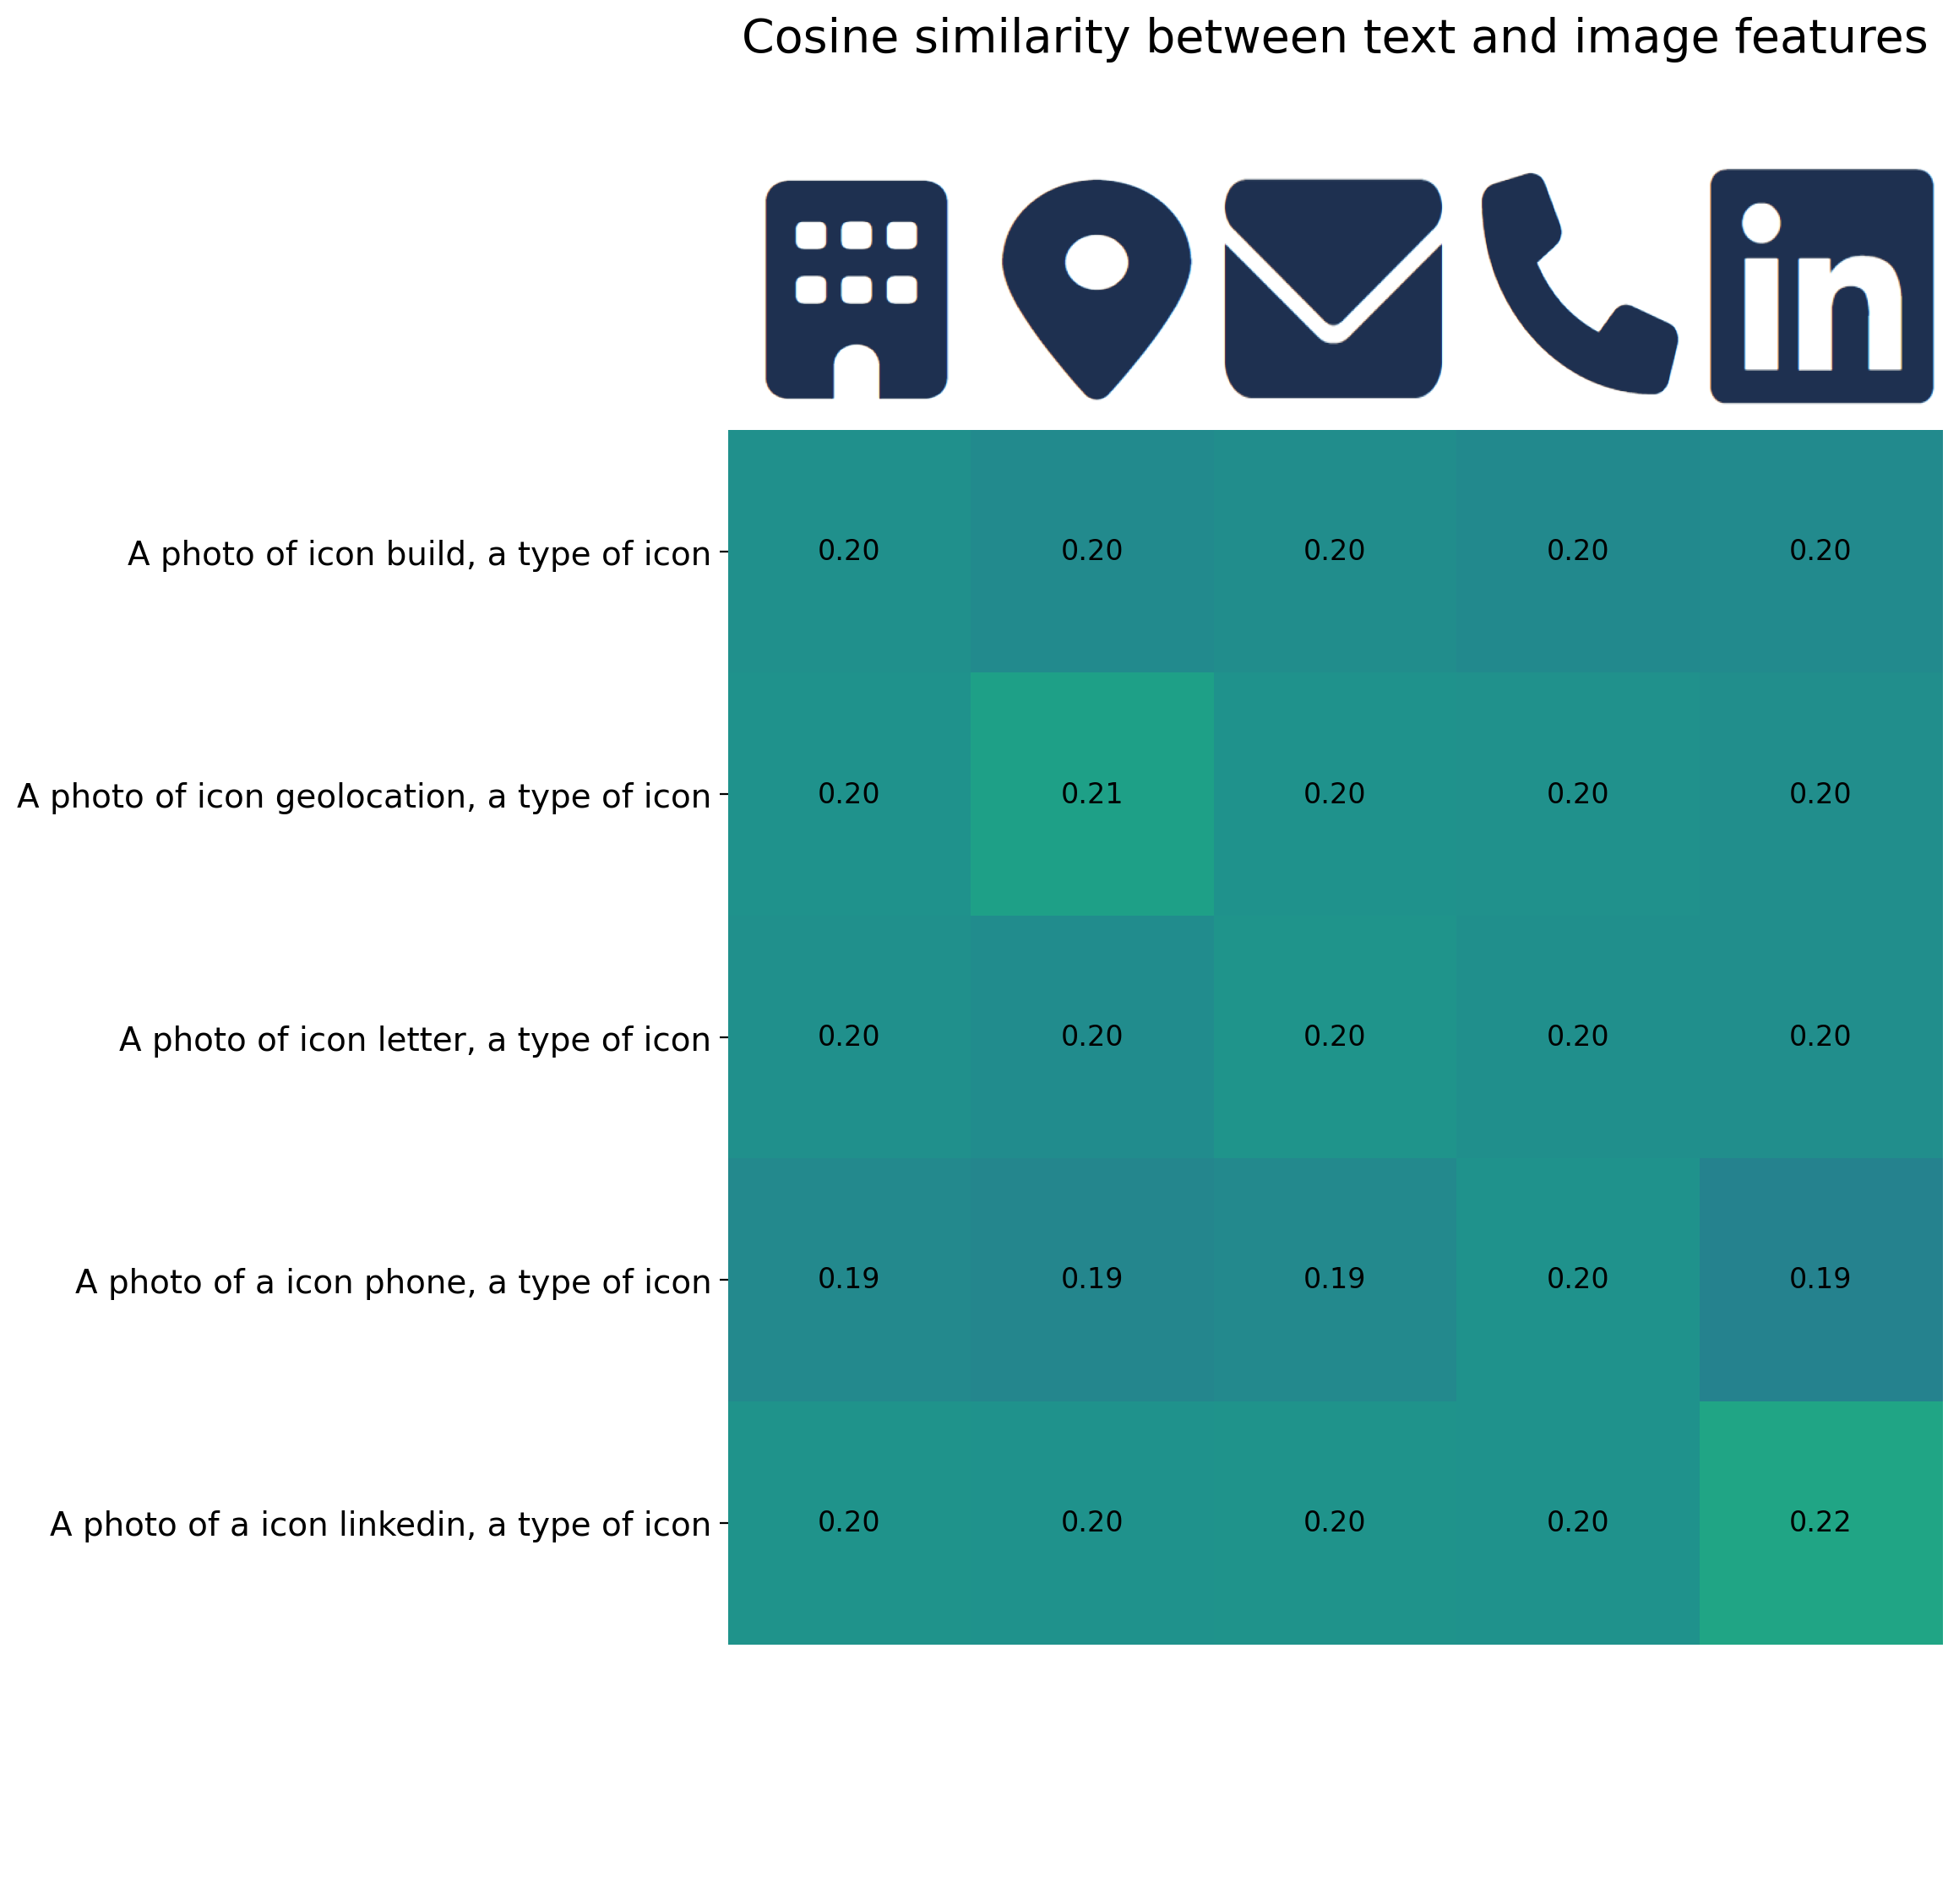

In [48]:
count = len(queries)

plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)

plt.yticks(range(count), queries, fontsize=14)
plt.xticks([])
for i, image in enumerate(images):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

for side in ["left", "top", "right", "bottom"]:
  plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])

plt.title("Cosine similarity between text and image features", size=20)
plt.show()